# House Price Prediction using Data Analytics with AI
IBM SkillsBuild Data Analytics with AI Internship 2026 | AICTE | BharatCares

This notebook walks through the whole project: load data, clean it, explore it, train models, compare them and save the best one.

## 1. Imports

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

%matplotlib inline

## 2. Load the data
If `data/house_price.csv` is missing, run `python data/generate_data.py` first.

In [2]:
path = "../data/house_price.csv" if os.path.exists("../data/house_price.csv") else "data/house_price.csv"
df = pd.read_csv(path)
print(df.shape)
df.head()

(1500, 8)


,city,area_sqft,bedrooms,bathrooms,age_years,location_score,parking,price
0,Lucknow,3223,4,3.0,34.0,5,0,9388000.0
1,Bengaluru,2851,3,4.0,3.0,1,1,14326000.0
2,Patna,3754,5,3.0,29.0,7,1,9835000.0
3,Pune,3862,4,3.0,20.0,5,0,14991000.0
4,Mumbai,2967,1,2.0,30.0,8,1,19940000.0


## 3. Data quality check

In [3]:
print(df.dtypes)
print()
print("missing values:")
print(df.isnull().sum())
print("duplicates:", df.duplicated().sum())

city                  str
area_sqft           int64
bedrooms            int64
bathrooms         float64
age_years         float64
location_score      int64
parking             int64
price             float64
dtype: object

missing values:
city              20
area_sqft          0
bedrooms           0
bathrooms         20
age_years         20
location_score     0
parking            0
price              0
dtype: int64
duplicates: 0


In [4]:
df.describe().round(2)

,area_sqft,bedrooms,bathrooms,age_years,location_score,parking,price
count,1500.00,1500.00,1480.00,1480.00,1500.00,1500.00,1500.00
mean,2225.75,3.00,2.46,19.24,5.48,1.01,11320542.00
std,1002.24,1.42,1.12,11.43,2.80,0.81,5327253.48
min,501.00,1.00,1.00,0.00,1.00,0.00,1070000.00
25%,1367.50,2.00,1.00,9.00,3.00,0.00,7309250.00
50%,2171.00,3.00,2.00,19.00,5.00,1.00,10268500.00
75%,3111.50,4.00,3.00,29.00,8.00,2.00,15091250.00
max,3999.00,5.00,4.00,39.00,10.00,2.00,29060000.00


## 4. Cleaning
Drop duplicates, fill numeric gaps with the median and the missing city with the most common one.

In [5]:
NUM_COLS = ["area_sqft", "bedrooms", "bathrooms", "age_years", "location_score", "parking"]
CAT_COLS = ["city"]
TARGET = "price"

df = df.drop_duplicates()
df[NUM_COLS] = df[NUM_COLS].fillna(df[NUM_COLS].median())
df[CAT_COLS] = df[CAT_COLS].fillna(df[CAT_COLS].mode().iloc[0])
print("missing after cleaning:", int(df.isnull().sum().sum()))

missing after cleaning: 0


## 5. Exploratory data analysis

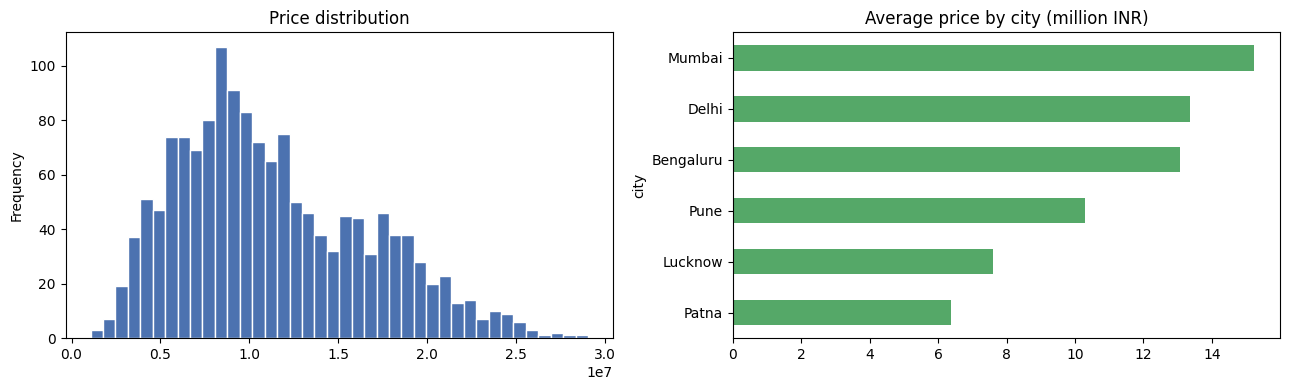

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
df[TARGET].plot(kind="hist", bins=40, ax=ax[0], color="#4c72b0", edgecolor="white")
ax[0].set_title("Price distribution")
(df.groupby("city")[TARGET].mean().sort_values() / 1e6).plot(kind="barh", ax=ax[1], color="#55a868")
ax[1].set_title("Average price by city (million INR)")
plt.tight_layout()
plt.show()

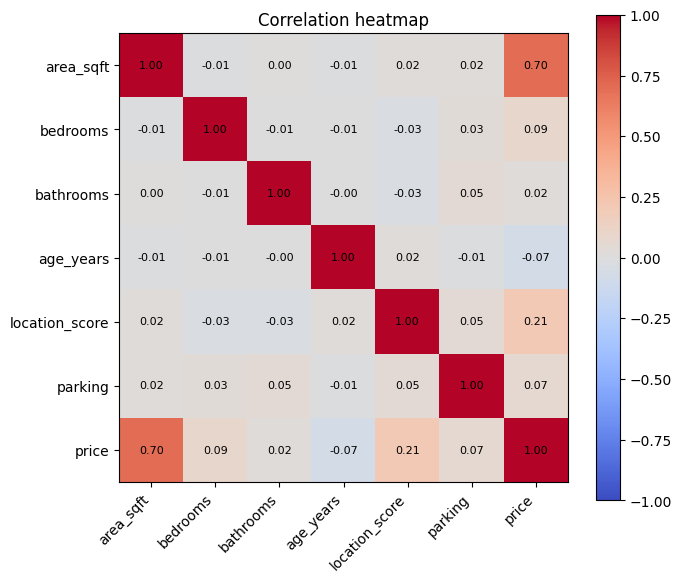

area_sqft         0.700
location_score    0.211
bedrooms          0.092
parking           0.067
bathrooms         0.020
age_years        -0.066
Name: price, dtype: float64


In [7]:
corr = df[NUM_COLS + [TARGET]].corr()
plt.figure(figsize=(7, 6))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr)), corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
plt.title("Correlation heatmap")
plt.tight_layout()
plt.show()

print(corr[TARGET].drop(TARGET).sort_values(ascending=False).round(3))

**Observations:** area and location score have the strongest link with price, house age pulls the price down, and the city changes the price level a lot, so city is kept as a feature.

## 6. Train and test split

In [8]:
X = df[NUM_COLS + CAT_COLS]
y = df[TARGET]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(1200, 7) (300, 7)


## 7. Models
Every model sits in the same pipeline (scale numbers, one-hot encode city), so prediction later uses exactly the same steps.

In [9]:
def build(reg):
    prep = ColumnTransformer([
        ("num", StandardScaler(), NUM_COLS),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CAT_COLS),
    ])
    return Pipeline([("prep", prep), ("reg", reg)])

candidates = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=1.0),
    "Random Forest": RandomForestRegressor(n_estimators=150, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
}

rows, fitted = [], {}
for name, reg in candidates.items():
    pipe = build(reg).fit(X_train, y_train)
    pred = pipe.predict(X_test)
    cv = cross_val_score(build(reg), X_train, y_train, cv=5, scoring="r2")
    rows.append({
        "model": name,
        "r2": round(r2_score(y_test, pred), 4),
        "cv_r2": round(cv.mean(), 4),
        "mae": int(mean_absolute_error(y_test, pred)),
        "rmse": int(mean_squared_error(y_test, pred) ** 0.5),
    })
    fitted[name] = pipe

results = pd.DataFrame(rows).sort_values("cv_r2", ascending=False).reset_index(drop=True)
results

,model,r2,cv_r2,mae,rmse
0,Gradient Boosting,0.9814,0.9610,551906,715974
1,Random Forest,0.9735,0.9506,630541,854639
2,Linear Regression,0.9429,0.9224,961331,1254247
3,Lasso,0.9429,0.9224,961331,1254247
4,Ridge,0.9429,0.9224,961734,1254078


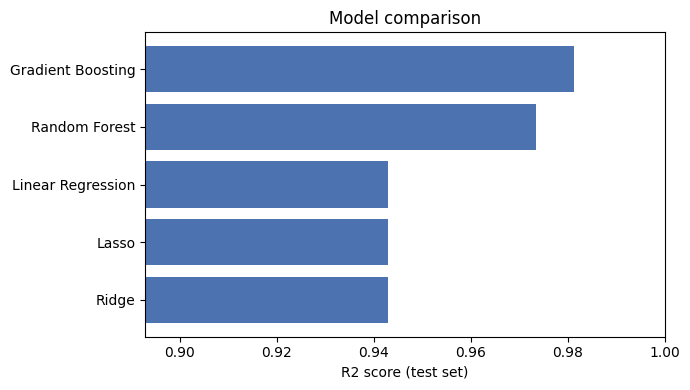

In [10]:
plt.figure(figsize=(7, 4))
plt.barh(results["model"][::-1], results["r2"][::-1], color="#4c72b0")
plt.xlim(max(0, results["r2"].min() - 0.05), 1)
plt.xlabel("R2 score (test set)")
plt.title("Model comparison")
plt.tight_layout()
plt.show()

## 8. Best model

best model: Gradient Boosting
R2  : 0.9814
MAE : 551906


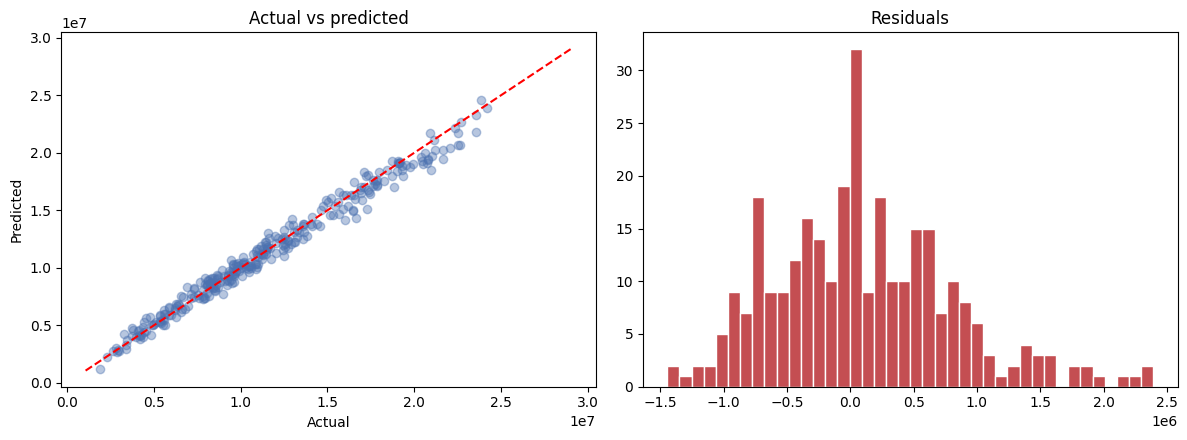

In [11]:
best_name = results.loc[0, "model"]
best = fitted[best_name]
pred = best.predict(X_test)
print("best model:", best_name)
print("R2  :", round(r2_score(y_test, pred), 4))
print("MAE :", int(mean_absolute_error(y_test, pred)))

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].scatter(y_test, pred, alpha=0.4, color="#4c72b0")
ax[0].plot([y.min(), y.max()], [y.min(), y.max()], "r--")
ax[0].set_xlabel("Actual")
ax[0].set_ylabel("Predicted")
ax[0].set_title("Actual vs predicted")
ax[1].hist(y_test - pred, bins=40, color="#c44e52", edgecolor="white")
ax[1].set_title("Residuals")
plt.tight_layout()
plt.show()

## 9. Feature importance

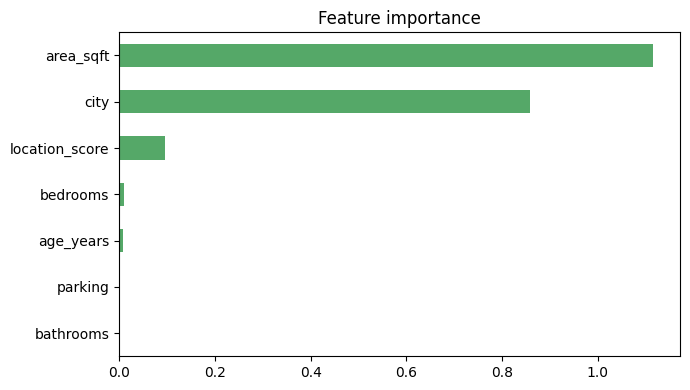

In [12]:
imp = permutation_importance(best, X_test, y_test, n_repeats=5, random_state=42)
pd.Series(imp.importances_mean, index=X_test.columns).sort_values().plot(kind="barh", color="#55a868", figsize=(7, 4))
plt.title("Feature importance")
plt.tight_layout()
plt.show()

## 10. Try a prediction

In [13]:
sample = pd.DataFrame([{
    "city": "Pune", "area_sqft": 1200, "bedrooms": 3, "bathrooms": 2,
    "age_years": 5, "location_score": 7, "parking": 1,
}])
print("Estimated price: Rs", f"{int(best.predict(sample)[0]):,}")

Estimated price: Rs 8,405,049


## 11. Save the model
The web app loads this file. (`train_model.py` does the same and also saves the report charts.)

In [14]:
os.makedirs("../model", exist_ok=True)
joblib.dump({
    "model": best, "name": best_name,
    "num_cols": NUM_COLS, "cat_cols": CAT_COLS,
    "cities": sorted(df["city"].unique().tolist()),
}, "../model/notebook_model.pkl")
print("saved")

saved


## Conclusion
The best model explains most of the variation in price. With real market data the score would be lower, and adding locality and furnishing details would be the next step.